# Cramér-Rao Lower Bound (CRLB): A Step-by-Step Journey

Welcome! This notebook will guide you through the **Cramér-Rao Lower Bound** from first principles. We'll build intuition by:
- Deriving each concept mathematically
- Visualizing what it means geometrically
- Connecting it to Direction-of-Arrival (DOA) estimation

By the end, you'll understand:
1. **Likelihood**: How we model data probabilistically
2. **Score**: The sensitivity of the likelihood to parameters
3. **Fisher Information**: How much information data contains
4. **CRLB**: The fundamental limit on estimation accuracy
5. **DOA Application**: How this applies to angle estimation

Let's begin!

---

## Step 1: The Likelihood Function – Modeling Your Data

### What is it?

The **likelihood** $L(\theta; X)$ is the probability of observing data $X$ given a parameter $\theta$:

$$
L(\theta; X) = p(X \mid \theta)
$$

We often work with the **log-likelihood** for mathematical convenience:

$$
\ell(\theta) = \log L(\theta; X) = \log p(X \mid \theta)
$$

### Why does it matter?

The **shape** of $\ell(\theta)$ tells us everything about how informative the data are:
- **Sharp peak** ⟹ Data strongly favor one $\theta$ value (high information)
- **Flat curve** ⟹ Data barely distinguish nearby $\theta$ values (low information)

The curvature (second derivative) of $\ell(\theta)$ will become the **Fisher Information**!

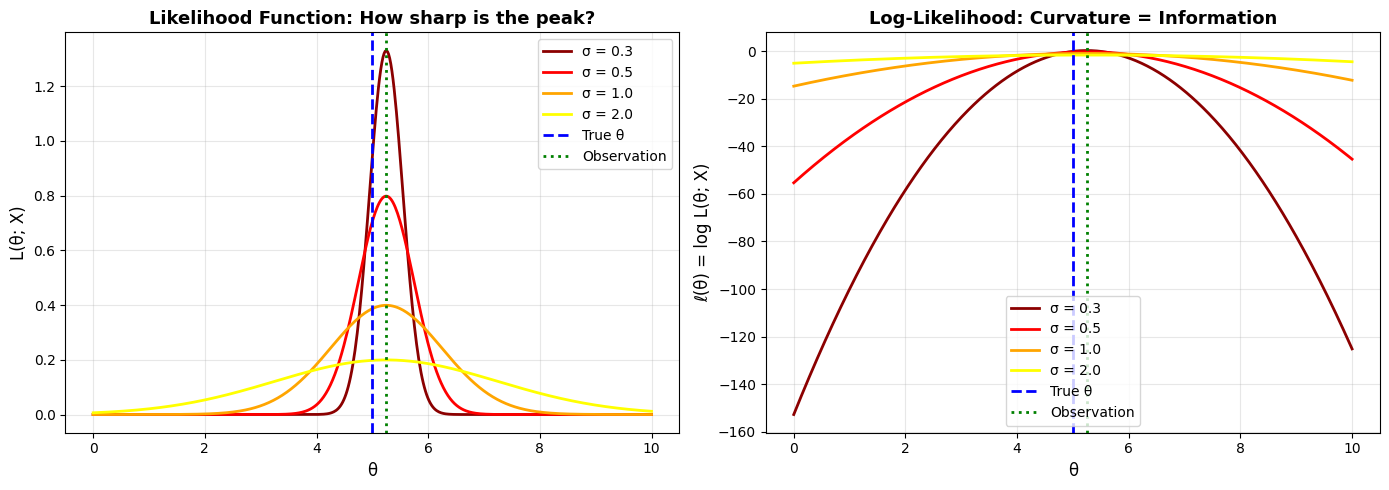

📊 Key Observations:
   • Observed data: X = 5.248
   • True parameter: θ = 5.000

   Lower noise (σ) → Sharper peak → More curvature → More information!
   Higher noise (σ) → Flatter peak → Less curvature → Less information!

   💡 The curvature of ℓ(θ) will become the Fisher Information!


In [1]:
"""
Step 1 Code: Visualizing the Likelihood Function

We'll simulate measuring a signal with Gaussian noise to see how 
the likelihood function changes with different noise levels.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set random seed for reproducibility
np.random.seed(42)

# True parameter value
theta_true = 5.0

# Generate observed data (one sample from Gaussian)
# We'll use different noise levels to see how it affects the likelihood
x_observed = theta_true + np.random.randn() * 0.5  # Low noise observation

# Create a range of possible theta values
theta_range = np.linspace(0, 10, 500)

# Compute likelihood for different noise levels (standard deviations)
noise_levels = [0.3, 0.5, 1.0, 2.0]
colors = ['darkred', 'red', 'orange', 'yellow']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Likelihood L(θ; X)
ax1 = axes[0]
for sigma, color in zip(noise_levels, colors):
    likelihood = norm.pdf(x_observed, loc=theta_range, scale=sigma)
    ax1.plot(theta_range, likelihood, label=f'σ = {sigma}', color=color, linewidth=2)

ax1.axvline(theta_true, color='blue', linestyle='--', linewidth=2, label='True θ')
ax1.axvline(x_observed, color='green', linestyle=':', linewidth=2, label='Observation')
ax1.set_xlabel('θ', fontsize=12)
ax1.set_ylabel('L(θ; X)', fontsize=12)
ax1.set_title('Likelihood Function: How sharp is the peak?', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: Log-Likelihood ℓ(θ)
ax2 = axes[1]
for sigma, color in zip(noise_levels, colors):
    log_likelihood = norm.logpdf(x_observed, loc=theta_range, scale=sigma)
    ax2.plot(theta_range, log_likelihood, label=f'σ = {sigma}', color=color, linewidth=2)

ax2.axvline(theta_true, color='blue', linestyle='--', linewidth=2, label='True θ')
ax2.axvline(x_observed, color='green', linestyle=':', linewidth=2, label='Observation')
ax2.set_xlabel('θ', fontsize=12)
ax2.set_ylabel('ℓ(θ) = log L(θ; X)', fontsize=12)
ax2.set_title('Log-Likelihood: Curvature = Information', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Key Observations:")
print(f"   • Observed data: X = {x_observed:.3f}")
print(f"   • True parameter: θ = {theta_true:.3f}")
print("\n   Lower noise (σ) → Sharper peak → More curvature → More information!")
print("   Higher noise (σ) → Flatter peak → Less curvature → Less information!")
print("\n   💡 The curvature of ℓ(θ) will become the Fisher Information!")

---

## Step 2: The Score Function – Measuring Sensitivity

### What is it?

The **score** is the gradient (derivative) of the log-likelihood with respect to the parameter:

$$
u(\theta) = \frac{\partial \ell(\theta)}{\partial \theta} = \frac{\partial}{\partial \theta} \log p(X \mid \theta)
$$

For vector parameters $\boldsymbol\theta$, it's a gradient vector:

$$
\mathbf{u}(\boldsymbol\theta) = \nabla_{\boldsymbol\theta} \ell(\boldsymbol\theta)
$$

### Why does it matter?

The score tells us **how sensitive** the log-likelihood is to changes in $\theta$:
- **Large score** ⟹ Small changes in $\theta$ produce big changes in likelihood
- **Zero score** ⟹ We're at a peak/trough (potential MLE)

### Two Key Properties (under regularity conditions):

1. **Zero mean at the true parameter**: 
   $$\mathbb{E}_{\theta}[u(\theta)] = 0$$
   
2. **Its variance IS the Fisher Information** (next step!):
   $$\mathrm{Var}(u(\theta)) = \mathbb{E}[u(\theta)^2] = J(\theta)$$

### Intuition

Think of the score as an "error signal":
- It points toward parameter values that make the data more likely
- On average (at the true $\theta$), it's zero (no bias)
- But its **variability** quantifies how much the data can tell us about $\theta$

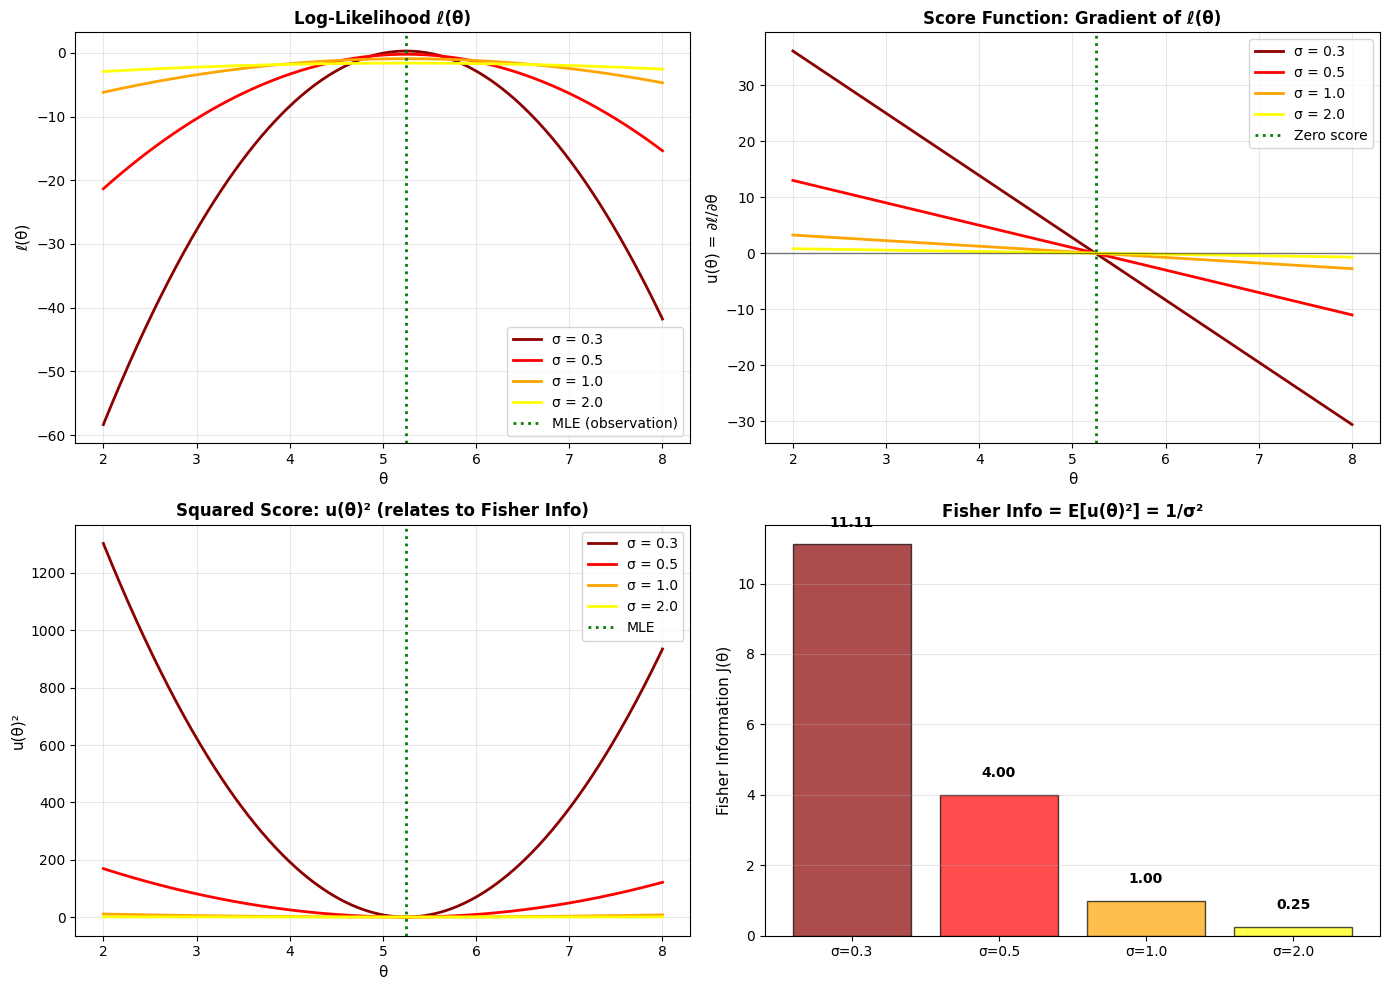

📊 Key Observations:
   • Score is ZERO at the MLE (θ = 5.248)
   • Score is POSITIVE when θ < observation (likelihood increases as θ increases)
   • Score is NEGATIVE when θ > observation (likelihood decreases as θ increases)

   Lower σ → Steeper score → Higher score variance → More information!
   Higher σ → Flatter score → Lower score variance → Less information!

   💡 The VARIANCE of the score = Fisher Information = 1/σ² (for Gaussian)
   💡 This is why curvature = information!


In [2]:
"""
Step 2 Code: Visualizing the Score Function

We'll compute and plot the score (derivative of log-likelihood) to see:
1. How the score varies across different θ values
2. That the score is zero at the peak of the likelihood
3. How the score's variance relates to information content
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Use the same setup as Step 1
np.random.seed(42)
theta_true = 5.0
x_observed = theta_true + np.random.randn() * 0.5

# Range of theta values
theta_range = np.linspace(2, 8, 500)
noise_levels = [0.3, 0.5, 1.0, 2.0]
colors = ['darkred', 'red', 'orange', 'yellow']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Log-Likelihood (reminder from Step 1)
ax1 = axes[0, 0]
for sigma, color in zip(noise_levels, colors):
    log_likelihood = norm.logpdf(x_observed, loc=theta_range, scale=sigma)
    ax1.plot(theta_range, log_likelihood, label=f'σ = {sigma}', color=color, linewidth=2)

ax1.axvline(x_observed, color='green', linestyle=':', linewidth=2, label='MLE (observation)')
ax1.set_xlabel('θ', fontsize=11)
ax1.set_ylabel('ℓ(θ)', fontsize=11)
ax1.set_title('Log-Likelihood ℓ(θ)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Top-right: Score function u(θ) = ∂ℓ/∂θ
ax2 = axes[0, 1]
for sigma, color in zip(noise_levels, colors):
    # For Gaussian: u(θ) = (x - θ) / σ²
    score = (x_observed - theta_range) / (sigma**2)
    ax2.plot(theta_range, score, label=f'σ = {sigma}', color=color, linewidth=2)

ax2.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax2.axvline(x_observed, color='green', linestyle=':', linewidth=2, label='Zero score')
ax2.set_xlabel('θ', fontsize=11)
ax2.set_ylabel('u(θ) = ∂ℓ/∂θ', fontsize=11)
ax2.set_title('Score Function: Gradient of ℓ(θ)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Bottom-left: Score² (will relate to Fisher Information)
ax3 = axes[1, 0]
for sigma, color in zip(noise_levels, colors):
    score = (x_observed - theta_range) / (sigma**2)
    score_squared = score**2
    ax3.plot(theta_range, score_squared, label=f'σ = {sigma}', color=color, linewidth=2)

ax3.axvline(x_observed, color='green', linestyle=':', linewidth=2, label='MLE')
ax3.set_xlabel('θ', fontsize=11)
ax3.set_ylabel('u(θ)²', fontsize=11)
ax3.set_title('Squared Score: u(θ)² (relates to Fisher Info)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Bottom-right: Expected value of score² (Fisher Information!)
ax4 = axes[1, 1]
fisher_info = [1/sigma**2 for sigma in noise_levels]
ax4.bar(range(len(noise_levels)), fisher_info, color=colors, alpha=0.7, edgecolor='black')
ax4.set_xticks(range(len(noise_levels)))
ax4.set_xticklabels([f'σ={s}' for s in noise_levels])
ax4.set_ylabel('Fisher Information J(θ)', fontsize=11)
ax4.set_title('Fisher Info = E[u(θ)²] = 1/σ²', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# Add annotation
for i, (sigma, fi) in enumerate(zip(noise_levels, fisher_info)):
    ax4.text(i, fi + 0.5, f'{fi:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("📊 Key Observations:")
print(f"   • Score is ZERO at the MLE (θ = {x_observed:.3f})")
print("   • Score is POSITIVE when θ < observation (likelihood increases as θ increases)")
print("   • Score is NEGATIVE when θ > observation (likelihood decreases as θ increases)")
print("\n   Lower σ → Steeper score → Higher score variance → More information!")
print("   Higher σ → Flatter score → Lower score variance → Less information!")
print("\n   💡 The VARIANCE of the score = Fisher Information = 1/σ² (for Gaussian)")
print("   💡 This is why curvature = information!")

---

## Step 3: Fisher Information Matrix (FIM) – Quantifying Information

### What is it?

The **Fisher Information** $J(\theta)$ is the variance of the score (or equivalently, minus the expected Hessian of the log-likelihood):

$$
J(\theta) = \mathbb{E}_{\theta}\left[u(\theta)^2\right] = \mathbb{E}_{\theta}\left[\left(\frac{\partial \ell}{\partial \theta}\right)^2\right] = -\mathbb{E}_{\theta}\left[\frac{\partial^2 \ell}{\partial \theta^2}\right]
$$

For vector parameters $\boldsymbol\theta = [\theta_1, \ldots, \theta_p]^T$, it becomes a **matrix**:

$$
\mathbf{J}(\boldsymbol\theta) = \mathbb{E}\left[\mathbf{u}(\boldsymbol\theta)\mathbf{u}(\boldsymbol\theta)^T\right] = -\mathbb{E}\left[\nabla^2_{\boldsymbol\theta} \ell(\boldsymbol\theta)\right]
$$

where $[\mathbf{J}]_{ij} = \mathbb{E}\left[\frac{\partial \ell}{\partial \theta_i}\frac{\partial \ell}{\partial \theta_j}\right]$

### Why does it matter?

Fisher Information measures **how curved** the log-likelihood is:
- **High curvature** (sharp peak) ⟹ Large $J$ ⟹ Data are very informative
- **Low curvature** (flat peak) ⟹ Small $J$ ⟹ Data are weakly informative

### Key Properties:

1. **IID samples add up**: For $T$ independent observations, $J_T = T \cdot J_1$
   
2. **Geometric interpretation**: $J$ is a Riemannian metric on the statistical manifold—it measures how distinguishable nearby parameters are

3. **The CRLB**: Any unbiased estimator $\hat{\theta}$ satisfies:
   $$\text{var}(\hat{\theta}) \geq \frac{1}{J(\theta)}$$
   
   For vector parameters: $\text{Cov}(\hat{\boldsymbol\theta}) \succeq \mathbf{J}^{-1}$ (positive semi-definite ordering)

### Example: Gaussian Location

For $X \sim \mathcal{N}(\theta, \sigma^2)$, the Fisher Information is:

$$
J(\theta) = \frac{1}{\sigma^2}
$$

This means: **Lower noise ⟹ Higher information ⟹ Better estimation possible!**

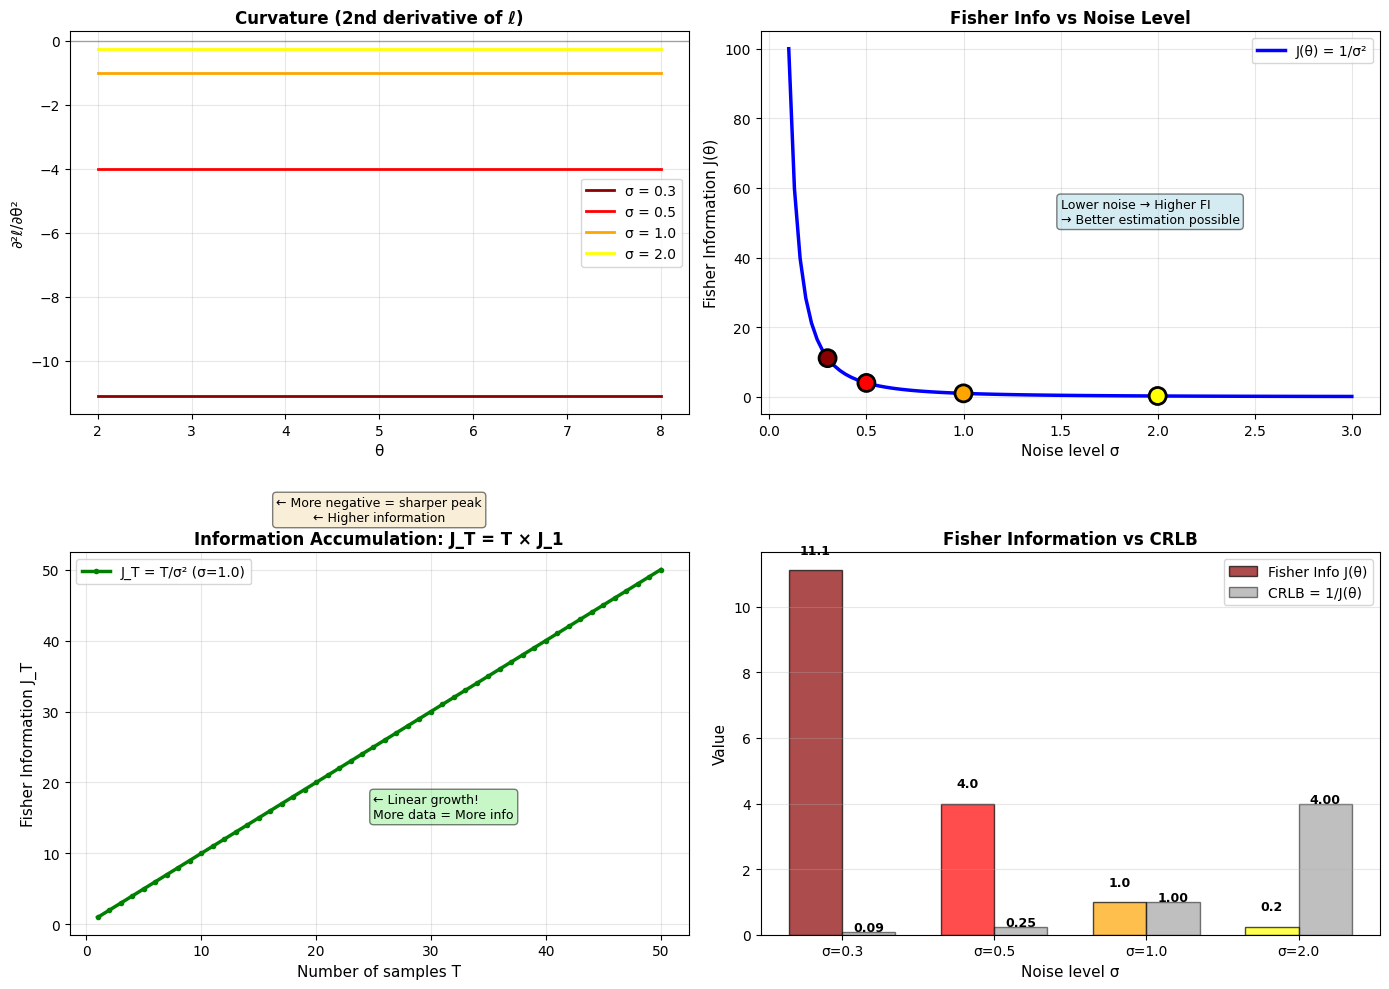

📊 Key Observations:

1. CURVATURE = INFORMATION:
   • Fisher Info = -E[∂²ℓ/∂θ²] (expected curvature)
   • Sharper log-likelihood → Larger J → More information

2. NOISE vs INFORMATION:
   • For Gaussian: J = 1/σ²
   • Lower noise → exponentially more information!

3. MULTIPLE SAMPLES:
   • J_T = T × J_1 (information adds linearly)
   • Doubling samples → doubles information

4. THE CRAMÉR-RAO BOUND:
   • No unbiased estimator can have variance < 1/J
   • CRLB = 1/J sets the fundamental limit
   • Higher J → Lower CRLB → Better possible precision

💡 Next: We'll derive the CRLB inequality and see how it all comes together!


In [3]:
"""
Step 3 Code: Visualizing Fisher Information

We'll demonstrate:
1. Computing Fisher Information analytically and empirically
2. How FI relates to the curvature of the log-likelihood
3. How multiple samples add information (J_T = T * J_1)
4. The connection to the CRLB
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)
theta_true = 5.0
noise_levels = [0.3, 0.5, 1.0, 2.0]
colors = ['darkred', 'red', 'orange', 'yellow']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ============================================================
# Top-left: Curvature (2nd derivative) of log-likelihood
# ============================================================
ax1 = axes[0, 0]
theta_range = np.linspace(2, 8, 500)

for sigma, color in zip(noise_levels, colors):
    # For Gaussian: d²ℓ/dθ² = -1/σ²
    curvature = -np.ones_like(theta_range) / (sigma**2)
    ax1.plot(theta_range, curvature, label=f'σ = {sigma}', color=color, linewidth=2)

ax1.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
ax1.set_xlabel('θ', fontsize=11)
ax1.set_ylabel('∂²ℓ/∂θ²', fontsize=11)
ax1.set_title('Curvature (2nd derivative of ℓ)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.text(5, -15, '← More negative = sharper peak\n← Higher information', 
         fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ============================================================
# Top-right: Fisher Information as a function of σ
# ============================================================
ax2 = axes[0, 1]
sigma_range = np.linspace(0.1, 3, 100)
fisher_continuous = 1 / (sigma_range**2)

ax2.plot(sigma_range, fisher_continuous, color='blue', linewidth=2.5, label='J(θ) = 1/σ²')
ax2.scatter(noise_levels, [1/s**2 for s in noise_levels], 
           color=colors, s=150, zorder=5, edgecolor='black', linewidth=2)

ax2.set_xlabel('Noise level σ', fontsize=11)
ax2.set_ylabel('Fisher Information J(θ)', fontsize=11)
ax2.set_title('Fisher Info vs Noise Level', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.text(1.5, 50, 'Lower noise → Higher FI\n→ Better estimation possible', 
         fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# ============================================================
# Bottom-left: Information accumulation with multiple samples
# ============================================================
ax3 = axes[1, 0]
num_samples_range = np.arange(1, 51)
sigma_fixed = 1.0

# J_T = T * J_1
fisher_vs_samples = num_samples_range / (sigma_fixed**2)

ax3.plot(num_samples_range, fisher_vs_samples, color='green', linewidth=2.5, marker='o', 
         markersize=3, label=f'J_T = T/σ² (σ={sigma_fixed})')
ax3.set_xlabel('Number of samples T', fontsize=11)
ax3.set_ylabel('Fisher Information J_T', fontsize=11)
ax3.set_title('Information Accumulation: J_T = T × J_1', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.text(25, 15, '← Linear growth!\nMore data = More info', 
         fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# ============================================================
# Bottom-right: CRLB = 1/J (the bound on estimator variance)
# ============================================================
ax4 = axes[1, 1]

# Create bars showing both J and CRLB
x_pos = np.arange(len(noise_levels))
fisher_values = [1/s**2 for s in noise_levels]
crlb_values = [s**2 for s in noise_levels]  # CRLB = 1/J

width = 0.35
bars1 = ax4.bar(x_pos - width/2, fisher_values, width, label='Fisher Info J(θ)', 
                color=colors, alpha=0.7, edgecolor='black')
bars2 = ax4.bar(x_pos + width/2, crlb_values, width, label='CRLB = 1/J(θ)', 
                color='gray', alpha=0.5, edgecolor='black')

ax4.set_xlabel('Noise level σ', fontsize=11)
ax4.set_ylabel('Value', fontsize=11)
ax4.set_title('Fisher Information vs CRLB', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels([f'σ={s}' for s in noise_levels])
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (fi, crlb) in enumerate(zip(fisher_values, crlb_values)):
    ax4.text(i - width/2, fi + 0.5, f'{fi:.1f}', ha='center', fontsize=9, fontweight='bold')
    ax4.text(i + width/2, crlb + 0.02, f'{crlb:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("📊 Key Observations:")
print("\n1. CURVATURE = INFORMATION:")
print("   • Fisher Info = -E[∂²ℓ/∂θ²] (expected curvature)")
print("   • Sharper log-likelihood → Larger J → More information")

print("\n2. NOISE vs INFORMATION:")
print("   • For Gaussian: J = 1/σ²")
print("   • Lower noise → exponentially more information!")

print("\n3. MULTIPLE SAMPLES:")
print("   • J_T = T × J_1 (information adds linearly)")
print("   • Doubling samples → doubles information")

print("\n4. THE CRAMÉR-RAO BOUND:")
print("   • No unbiased estimator can have variance < 1/J")
print("   • CRLB = 1/J sets the fundamental limit")
print("   • Higher J → Lower CRLB → Better possible precision")

print("\n💡 Next: We'll derive the CRLB inequality and see how it all comes together!")

---

## Step 4: The Cramér-Rao Inequality – Deriving the Bound

### The Main Result

For any **unbiased** estimator $\hat{\theta}(X)$ of parameter $\theta$, we have:

$$
\text{var}(\hat{\theta}) \geq \frac{1}{J(\theta)} = \text{CRLB}(\theta)
$$

For **vector parameters** $\boldsymbol\theta$:

$$
\text{Cov}(\hat{\boldsymbol\theta}) \succeq \mathbf{J}^{-1}(\boldsymbol\theta)
$$

where $\succeq$ means "positive semi-definite" (the difference of matrices is PSD).

### Proof Sketch (Scalar Case)

The proof uses a clever application of the **Cauchy-Schwarz inequality**:

1. **Start with unbiasedness**: $\mathbb{E}[\hat{\theta}] = \theta$ for all $\theta$

2. **Differentiate both sides** w.r.t. $\theta$ (interchange derivative and expectation):
   $$
   \frac{d}{d\theta}\mathbb{E}[\hat{\theta}] = 1
   $$
   
3. **Apply the product rule** under the integral:
   $$
   \mathbb{E}\left[(\hat{\theta} - \theta) \cdot u(\theta)\right] = 1
   $$
   where $u(\theta) = \frac{\partial \ell}{\partial \theta}$ is the score.

4. **Apply Cauchy-Schwarz**: For random variables $A$ and $B$:
   $$
   [\mathbb{E}[AB]]^2 \leq \mathbb{E}[A^2] \cdot \mathbb{E}[B^2]
   $$
   
   Set $A = \hat{\theta} - \theta$ and $B = u(\theta)$:
   $$
   1 = [\mathbb{E}[(\hat{\theta}-\theta) \cdot u(\theta)]]^2 \leq \mathbb{E}[(\hat{\theta}-\theta)^2] \cdot \mathbb{E}[u(\theta)^2]
   $$

5. **Rearrange**:
   $$
   \text{var}(\hat{\theta}) = \mathbb{E}[(\hat{\theta}-\theta)^2] \geq \frac{1}{\mathbb{E}[u(\theta)^2]} = \frac{1}{J(\theta)}
   $$

### Key Insights

1. **The bound is tight**: Equality holds when $\hat{\theta} - \theta$ is proportional to $u(\theta)$
   - This happens for exponential families → MLE achieves CRLB asymptotically!

2. **Unbiasedness is crucial**: Biased estimators can have lower variance, but they trade variance for bias

3. **Fisher Information is the bottleneck**: You cannot extract more information than what's in the data

### For Biased Estimators

If $\mathbb{E}[\hat{\theta}] = \theta + b(\theta)$ (bias $b(\theta)$), then:

$$
\text{var}(\hat{\theta}) \geq \frac{(1 + b'(\theta))^2}{J(\theta)}
$$

Trade-off: You can have lower variance with bias, but MSE might still be higher.

Fisher Information (1 sample): J = 1.000
CRLB (1 sample): 1/J = 1.000


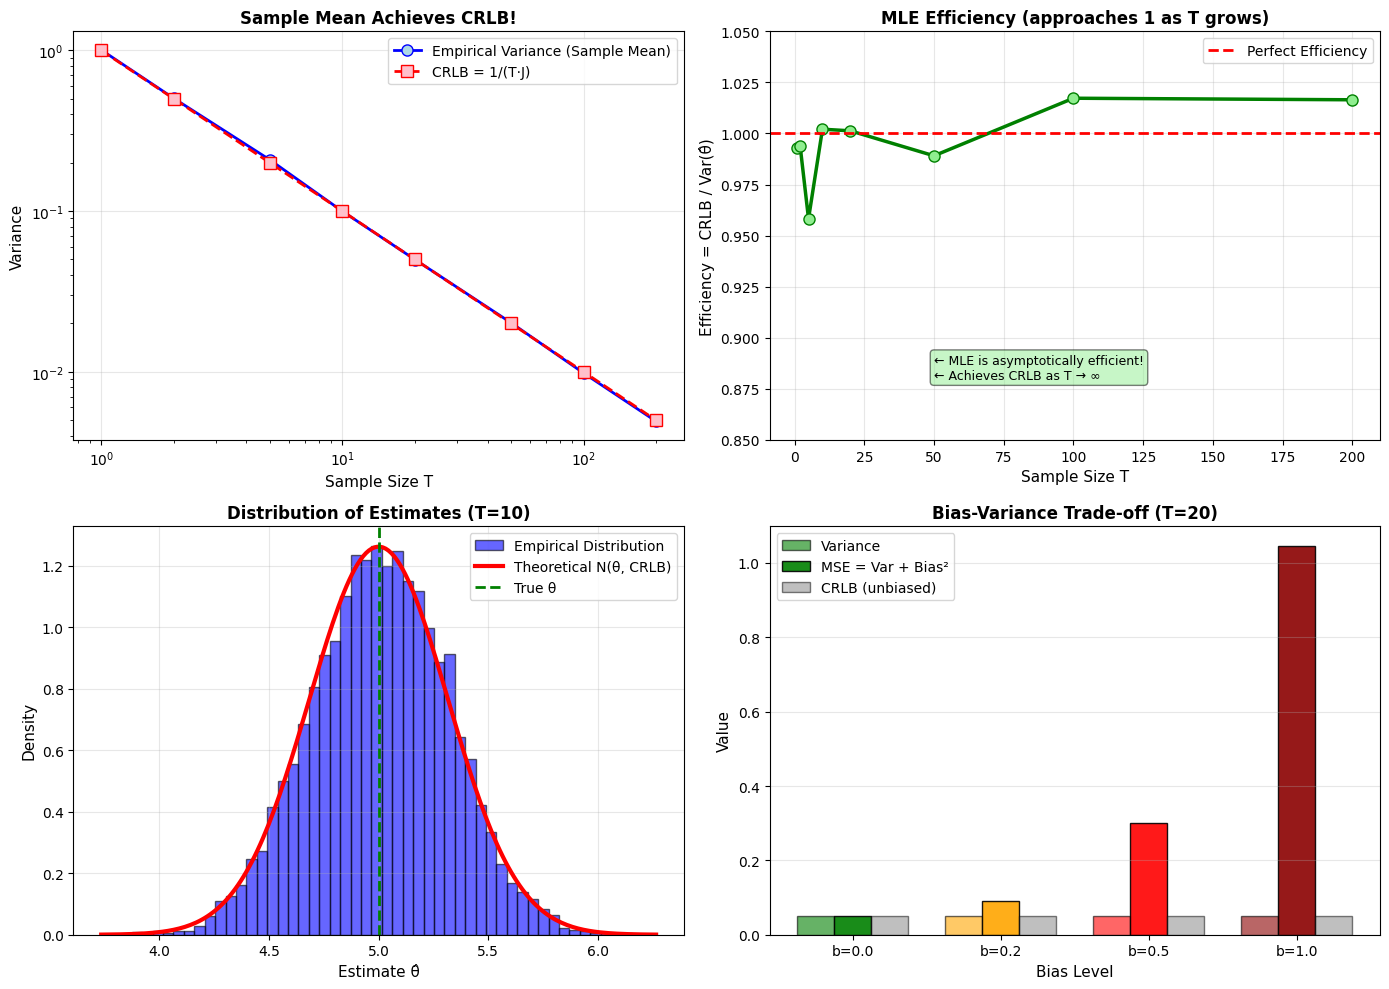


📊 Key Observations:

1. ACHIEVING THE CRLB:
   • Sample mean (MLE) variance closely matches CRLB
   • Efficiency → 1 as sample size increases
   • MLE is asymptotically efficient!

2. SAMPLE SIZE SCALING:
   • T=1:   CRLB = 1.000
   • T=10:  CRLB = 0.1000  (10× reduction)
   • T=100: CRLB = 0.01000  (100× reduction)
   • Variance decreases as 1/T

3. THE INEQUALITY:
   • var(θ̂) ≥ 1/J  holds for ALL unbiased estimators
   • No unbiased estimator can do better than CRLB
   • MLE achieves this bound (asymptotically)

4. BIASED ESTIMATORS:
   • Can have lower variance than CRLB
   • But MSE = Variance + Bias² is usually worse
   • CRLB only bounds variance, not MSE

💡 Next: We'll apply CRLB to DOA estimation!


In [4]:
"""
Step 4 Code: Demonstrating the CRLB Inequality

We'll:
1. Simulate multiple estimators (sample mean with different sample sizes)
2. Compute their empirical variances
3. Compare them to the CRLB
4. Show that good estimators approach the CRLB
5. Show what happens with biased estimators
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# True parameter
theta_true = 5.0
sigma = 1.0

# Fisher Information for single sample
J_1 = 1 / (sigma**2)
print(f"Fisher Information (1 sample): J = {J_1:.3f}")
print(f"CRLB (1 sample): 1/J = {1/J_1:.3f}")

# Sample sizes to test
sample_sizes = [1, 2, 5, 10, 20, 50, 100, 200]
num_trials = 10000

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ============================================================
# Top-left: Empirical variance vs CRLB for different sample sizes
# ============================================================
ax1 = axes[0, 0]

empirical_vars = []
crlb_values = []

for T in sample_sizes:
    # Generate many estimates
    estimates = []
    for _ in range(num_trials):
        # Generate T samples and compute sample mean (MLE)
        samples = np.random.normal(theta_true, sigma, T)
        estimate = np.mean(samples)
        estimates.append(estimate)
    
    # Compute empirical variance
    emp_var = np.var(estimates, ddof=1)
    empirical_vars.append(emp_var)
    
    # Theoretical CRLB
    crlb = 1 / (T * J_1)  # J_T = T * J_1
    crlb_values.append(crlb)

ax1.plot(sample_sizes, empirical_vars, 'o-', color='blue', linewidth=2, 
         markersize=8, label='Empirical Variance (Sample Mean)', markerfacecolor='lightblue')
ax1.plot(sample_sizes, crlb_values, 's--', color='red', linewidth=2, 
         markersize=8, label='CRLB = 1/(T·J)', markerfacecolor='pink')
ax1.set_xlabel('Sample Size T', fontsize=11)
ax1.set_ylabel('Variance', fontsize=11)
ax1.set_title('Sample Mean Achieves CRLB!', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

# ============================================================
# Top-right: Efficiency = CRLB / Empirical Variance
# ============================================================
ax2 = axes[0, 1]

efficiency = [crlb / emp_var for crlb, emp_var in zip(crlb_values, empirical_vars)]

ax2.plot(sample_sizes, efficiency, 'o-', color='green', linewidth=2.5, 
         markersize=8, markerfacecolor='lightgreen')
ax2.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Perfect Efficiency')
ax2.set_xlabel('Sample Size T', fontsize=11)
ax2.set_ylabel('Efficiency = CRLB / Var(θ̂)', fontsize=11)
ax2.set_title('MLE Efficiency (approaches 1 as T grows)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.85, 1.05])
ax2.text(50, 0.88, '← MLE is asymptotically efficient!\n← Achieves CRLB as T → ∞', 
         fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# ============================================================
# Bottom-left: Distribution of estimates for T=10
# ============================================================
ax3 = axes[1, 0]

T_demo = 10
estimates_demo = []
for _ in range(num_trials):
    samples = np.random.normal(theta_true, sigma, T_demo)
    estimate = np.mean(samples)
    estimates_demo.append(estimate)

# Theoretical distribution
crlb_T = 1 / (T_demo * J_1)
x_theory = np.linspace(theta_true - 4*np.sqrt(crlb_T), theta_true + 4*np.sqrt(crlb_T), 200)
y_theory = norm.pdf(x_theory, loc=theta_true, scale=np.sqrt(crlb_T))

ax3.hist(estimates_demo, bins=50, density=True, alpha=0.6, color='blue', 
         edgecolor='black', label='Empirical Distribution')
ax3.plot(x_theory, y_theory, 'r-', linewidth=3, label=f'Theoretical N(θ, CRLB)')
ax3.axvline(theta_true, color='green', linestyle='--', linewidth=2, label='True θ')
ax3.set_xlabel('Estimate θ̂', fontsize=11)
ax3.set_ylabel('Density', fontsize=11)
ax3.set_title(f'Distribution of Estimates (T={T_demo})', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# ============================================================
# Bottom-right: Biased vs Unbiased Estimators
# ============================================================
ax4 = axes[1, 1]

T_bias = 20
bias_values = [0.0, 0.2, 0.5, 1.0]  # Different bias levels
colors_bias = ['green', 'orange', 'red', 'darkred']

variances_biased = []
mse_values = []
crlb_biased = []

for bias in bias_values:
    estimates = []
    for _ in range(num_trials):
        samples = np.random.normal(theta_true, sigma, T_bias)
        estimate = np.mean(samples) + bias  # Add bias
        estimates.append(estimate)
    
    var_biased = np.var(estimates, ddof=1)
    mse = np.mean([(est - theta_true)**2 for est in estimates])
    
    variances_biased.append(var_biased)
    mse_values.append(mse)
    
    # Modified CRLB for biased estimator: (1 + b')² / J
    # For constant bias b, b' = 0, so CRLB_biased = 1/J (same!)
    crlb_biased.append(1 / (T_bias * J_1))

x_pos = np.arange(len(bias_values))
width = 0.25

bars1 = ax4.bar(x_pos - width, variances_biased, width, label='Variance', 
                color=colors_bias, alpha=0.6, edgecolor='black')
bars2 = ax4.bar(x_pos, mse_values, width, label='MSE = Var + Bias²', 
                color=colors_bias, alpha=0.9, edgecolor='black')
bars3 = ax4.bar(x_pos + width, crlb_biased, width, label='CRLB (unbiased)', 
                color='gray', alpha=0.5, edgecolor='black')

ax4.set_xlabel('Bias Level', fontsize=11)
ax4.set_ylabel('Value', fontsize=11)
ax4.set_title(f'Bias-Variance Trade-off (T={T_bias})', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels([f'b={b:.1f}' for b in bias_values])
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📊 Key Observations:")
print("="*60)

print("\n1. ACHIEVING THE CRLB:")
print("   • Sample mean (MLE) variance closely matches CRLB")
print("   • Efficiency → 1 as sample size increases")
print("   • MLE is asymptotically efficient!")

print("\n2. SAMPLE SIZE SCALING:")
print(f"   • T=1:   CRLB = {crlb_values[0]:.3f}")
print(f"   • T=10:  CRLB = {crlb_values[3]:.4f}  (10× reduction)")
print(f"   • T=100: CRLB = {crlb_values[6]:.5f}  (100× reduction)")
print("   • Variance decreases as 1/T")

print("\n3. THE INEQUALITY:")
print("   • var(θ̂) ≥ 1/J  holds for ALL unbiased estimators")
print("   • No unbiased estimator can do better than CRLB")
print("   • MLE achieves this bound (asymptotically)")

print("\n4. BIASED ESTIMATORS:")
print("   • Can have lower variance than CRLB")
print("   • But MSE = Variance + Bias² is usually worse")
print("   • CRLB only bounds variance, not MSE")

print("\n💡 Next: We'll apply CRLB to DOA estimation!")

---

## Step 5: CRLB for DOA Estimation – Putting It All Together

### The DOA Problem

We have an array of $M$ sensors receiving signals from $K$ sources at angles $\boldsymbol\theta = [\theta_1, \ldots, \theta_K]^T$. Over $T$ time snapshots, we observe:

$$
\mathbf{x}(t) = \mathbf{A}(\boldsymbol\theta)\mathbf{s}(t) + \mathbf{n}(t), \quad t=1,\ldots,T
$$

where:
- $\mathbf{A}(\boldsymbol\theta) = [\mathbf{a}(\theta_1), \ldots, \mathbf{a}(\theta_K)] \in \mathbb{C}^{M \times K}$ is the steering matrix
- $\mathbf{a}(\theta_k) = [1, e^{j\pi\sin\theta_k}, e^{j2\pi\sin\theta_k}, \ldots, e^{j(M-1)\pi\sin\theta_k}]^T$ for ULA
- $\mathbf{s}(t) \sim \mathcal{CN}(\mathbf{0}, \boldsymbol\Sigma_s)$ are the source signals (power matrix $\boldsymbol\Sigma_s$)
- $\mathbf{n}(t) \sim \mathcal{CN}(\mathbf{0}, \sigma^2\mathbf{I})$ is white Gaussian noise

### Two Models for CRLB

#### 1. **Conditional Model** (deterministic signals)
Treats $\mathbf{s}(t)$ as unknown deterministic parameters → higher dimensional problem

#### 2. **Unconditional Model** (stochastic signals) ⭐
Treats $\mathbf{s}(t)$ as random → work directly with the covariance matrix:

$$
\mathbf{R}(\boldsymbol\theta) = \mathbb{E}[\mathbf{x}(t)\mathbf{x}(t)^H] = \mathbf{A}(\boldsymbol\theta)\boldsymbol\Sigma_s\mathbf{A}(\boldsymbol\theta)^H + \sigma^2\mathbf{I}
$$

The likelihood becomes: $\mathbf{x}(t) \sim \mathcal{CN}(\mathbf{0}, \mathbf{R}(\boldsymbol\theta))$

### Slepian-Bangs Formula

For complex Gaussian with covariance depending on $\boldsymbol\theta$:

$$
[\mathbf{J}]_{ij} = T \cdot \text{Tr}\left(\mathbf{R}^{-1}\frac{\partial \mathbf{R}}{\partial \theta_i}\mathbf{R}^{-1}\frac{\partial \mathbf{R}}{\partial \theta_j}\right)
$$

The **CRLB** is then:
$$
\text{CRLB}(\theta_k) = [\mathbf{J}^{-1}]_{kk}
$$

### Key Derivative (for ULA)

$$
\frac{\partial \mathbf{a}(\theta)}{\partial \theta} = \mathbf{d}(\theta) = j\pi\cos\theta \cdot [0, 1, 2, \ldots, M-1]^T \odot \mathbf{a}(\theta)
$$

where $\odot$ is element-wise multiplication.

### What Affects DOA CRLB?

1. **SNR** ($\sigma^2$): Lower noise → Lower CRLB ✓
2. **Number of snapshots** ($T$): More data → Lower CRLB (scales as $1/T$) ✓
3. **Number of sensors** ($M$): More sensors → Lower CRLB ✓
4. **Source separation** ($|\theta_i - \theta_j|$): Closer sources → Higher CRLB (harder!) ⚠️
5. **Array geometry**: Better aperture → Lower CRLB ✓

### The Threshold Phenomenon

- **High SNR**: Algorithms like MUSIC/ESPRIT can approach CRLB
- **Low SNR/Close sources**: Estimators "break down" → actual error >> CRLB
- **Ziv-Zakai Bound (ZZB)**: A tighter (but harder to compute) bound that accounts for threshold effects

Array Configuration: M = 8 sensors (ULA)
Angle Convention: θ ∈ [0°, 180°] (cosine convention)


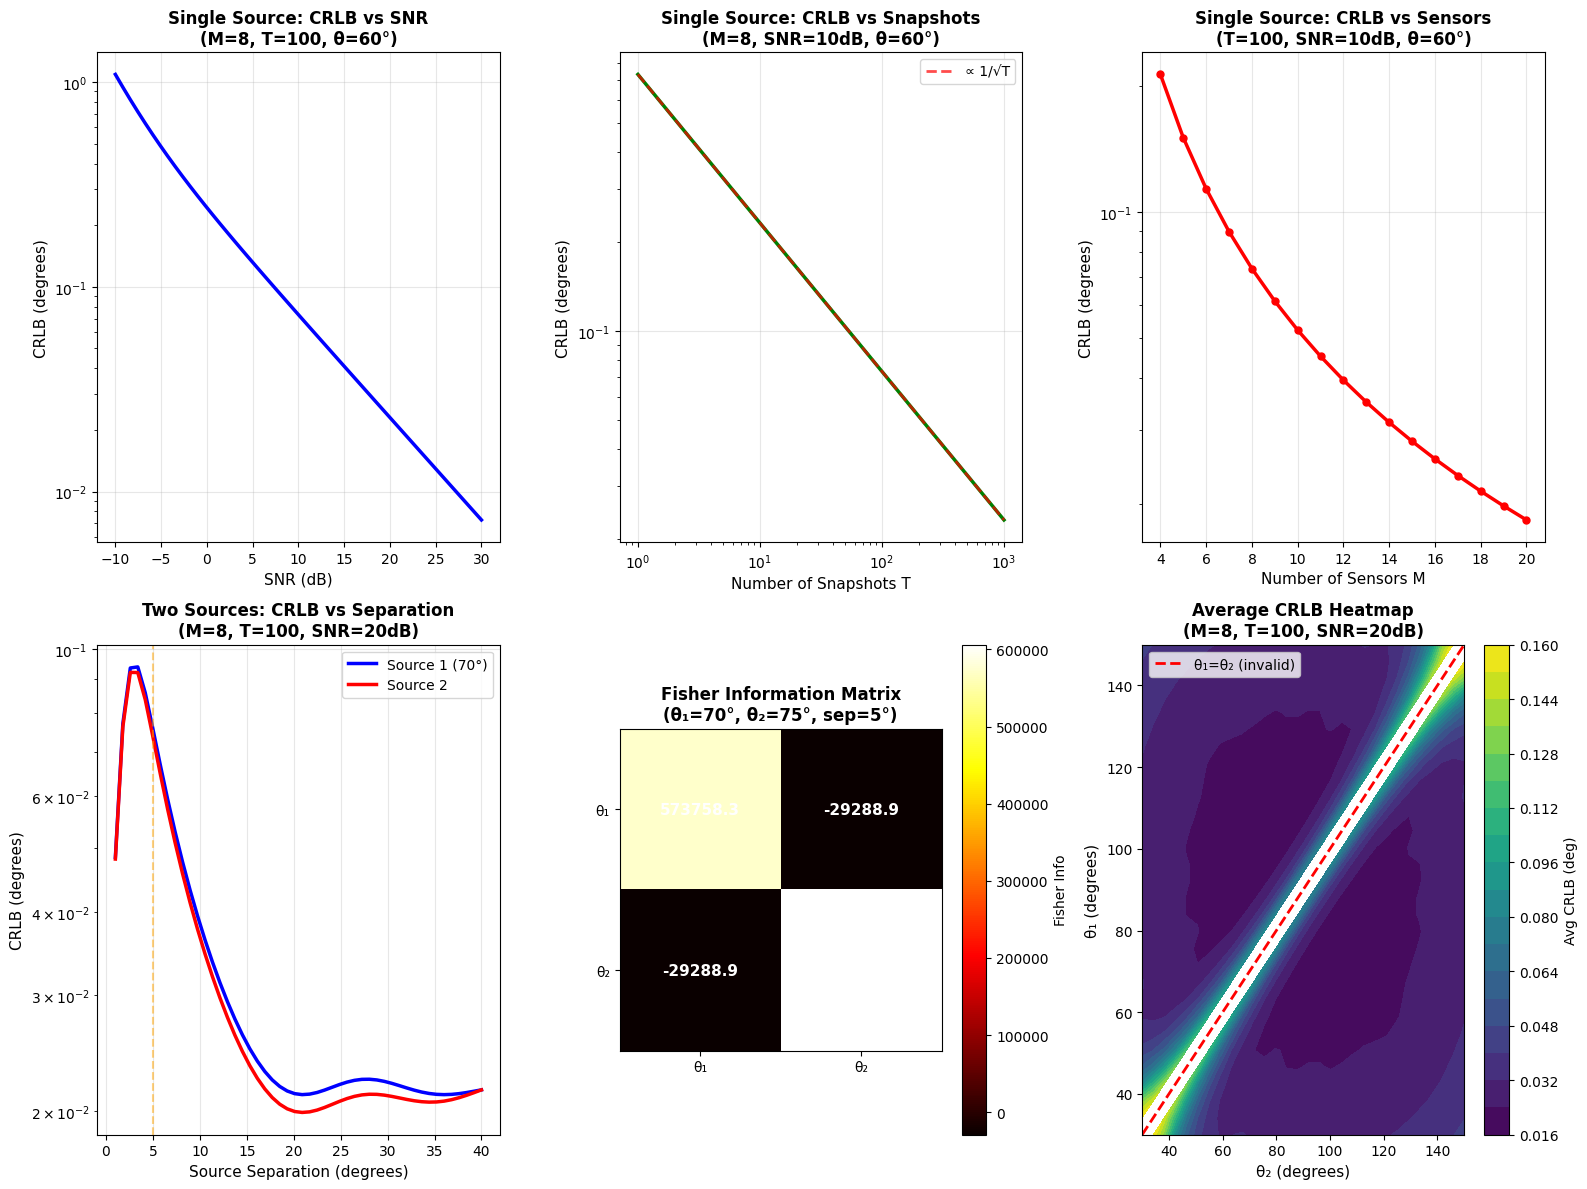


📊 Key Observations for DOA Estimation:

1. SNR EFFECT:
   • Higher SNR → Exponentially lower CRLB
   • At low SNR, CRLB grows rapidly
   • 10 dB increase → ~3× improvement

2. SNAPSHOT EFFECT:
   • CRLB ∝ 1/√T (standard deviation)
   • Variance ∝ 1/T
   • More data always helps!

3. ARRAY SIZE EFFECT:
   • More sensors → Lower CRLB
   • Diminishing returns after certain M
   • Larger aperture = better resolution

4. SOURCE SEPARATION:
   • ⚠️ CRITICAL FACTOR!
   • Close sources → Much higher CRLB
   • FIM has off-diagonal terms (coupling)
   • Below ~3-5° separation → resolution limit

5. FISHER INFORMATION MATRIX:
   • Diagonal: self-information of each source
   • Off-diagonal: coupling between sources
   • Close sources → strong coupling → harder estimation

💡 CRLB tells us the BEST POSSIBLE performance!
   Real algorithms (MUSIC, ESPRIT, deep learning) should be compared against CRLB

📐 Angle Convention: θ ∈ [0°, 180°]
   • 0° = endfire (left)
   • 90° = broadside (perpendicular)


In [5]:
"""
Step 5 Code: CRLB for DOA Estimation

We'll compute and visualize the CRLB for a simple DOA scenario:
1. Single source: see how CRLB depends on SNR, T, M
2. Two sources: see the coupling effect and source separation
3. Compare with actual estimator performance

Using COSINE convention: θ ∈ [0°, 180°], steering vector uses cos(θ)
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Helper Functions (COSINE CONVENTION)
# ============================================================

def steering_vector(theta, M):
    """
    Compute steering vector for ULA at angle theta (in radians)
    Using COSINE convention: θ ∈ [0, π]
    a(θ) = [1, e^{jπ cos(θ)}, e^{j2π cos(θ)}, ..., e^{j(M-1)π cos(θ)}]^T
    """
    m = np.arange(M)
    return np.exp(1j * np.pi * m * np.cos(theta))

def steering_vector_derivative(theta, M):
    """
    Compute derivative of steering vector w.r.t. theta
    da/dθ = -jπ sin(θ) * [0, 1, 2, ..., M-1]^T ⊙ a(θ)
    """
    m = np.arange(M)
    a = steering_vector(theta, M)
    return -1j * np.pi * np.sin(theta) * m * a

def covariance_matrix(thetas, powers, sigma2, M):
    """Compute covariance matrix R = A*Sigma_s*A^H + sigma^2*I"""
    K = len(thetas)
    A = np.column_stack([steering_vector(theta, M) for theta in thetas])
    Sigma_s = np.diag(powers)
    R = A @ Sigma_s @ A.conj().T + sigma2 * np.eye(M)
    return R, A

def compute_FIM_DOA(thetas, powers, sigma2, M, T):
    """
    Compute Fisher Information Matrix for DOA estimation
    using Slepian-Bangs formula (unconditional model)
    """
    K = len(thetas)
    R, A = covariance_matrix(thetas, powers, sigma2, M)
    R_inv = np.linalg.inv(R)
    
    # Compute derivatives dR/dtheta_k
    dR_list = []
    for k in range(K):
        d_k = steering_vector_derivative(thetas[k], M)
        # dR/dtheta_k = d_k * P_k * A[:,k]^H + A[:,k] * P_k * d_k^H
        dR = powers[k] * (np.outer(d_k, A[:, k].conj()) + np.outer(A[:, k], d_k.conj()))
        dR_list.append(dR)
    
    # Compute FIM using Slepian-Bangs
    FIM = np.zeros((K, K))
    for i in range(K):
        for j in range(K):
            FIM[i, j] = T * np.real(np.trace(R_inv @ dR_list[i] @ R_inv @ dR_list[j]))
    
    return FIM

def compute_CRLB(thetas, powers, sigma2, M, T):
    """Compute CRLB = diagonal of FIM^{-1}"""
    FIM = compute_FIM_DOA(thetas, powers, sigma2, M, T)
    try:
        CRLB = np.linalg.inv(FIM)
        return np.sqrt(np.diag(CRLB))  # Return standard deviation (RMSE bound)
    except:
        return np.full(len(thetas), np.inf)

# ============================================================
# Simulation Setup
# ============================================================

M = 8  # Number of sensors
print(f"Array Configuration: M = {M} sensors (ULA)")
print("Angle Convention: θ ∈ [0°, 180°] (cosine convention)")
print("="*60)

fig = plt.figure(figsize=(16, 12))

# ============================================================
# Plot 1: Single Source - CRLB vs SNR
# ============================================================
ax1 = plt.subplot(2, 3, 1)

theta_single = np.radians(60)  # 60 degrees (broadside would be 90°)
T = 100
P = 1.0  # Source power

SNR_dB_range = np.linspace(-10, 30, 50)
crlb_vs_snr = []

for SNR_dB in SNR_dB_range:
    sigma2 = P / (10**(SNR_dB/10))
    crlb_rad = compute_CRLB([theta_single], [P], sigma2, M, T)[0]
    crlb_deg = np.degrees(crlb_rad)
    crlb_vs_snr.append(crlb_deg)

ax1.semilogy(SNR_dB_range, crlb_vs_snr, 'b-', linewidth=2.5)
ax1.set_xlabel('SNR (dB)', fontsize=11)
ax1.set_ylabel('CRLB (degrees)', fontsize=11)
ax1.set_title(f'Single Source: CRLB vs SNR\n(M={M}, T={T}, θ=60°)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# ============================================================
# Plot 2: Single Source - CRLB vs Number of Snapshots
# ============================================================
ax2 = plt.subplot(2, 3, 2)

SNR_dB = 10
sigma2 = P / (10**(SNR_dB/10))
T_range = np.logspace(0, 3, 50).astype(int)  # 1 to 1000
crlb_vs_T = []

for T in T_range:
    crlb_rad = compute_CRLB([theta_single], [P], sigma2, M, T)[0]
    crlb_deg = np.degrees(crlb_rad)
    crlb_vs_T.append(crlb_deg)

ax2.loglog(T_range, crlb_vs_T, 'g-', linewidth=2.5)
ax2.set_xlabel('Number of Snapshots T', fontsize=11)
ax2.set_ylabel('CRLB (degrees)', fontsize=11)
ax2.set_title(f'Single Source: CRLB vs Snapshots\n(M={M}, SNR={SNR_dB}dB, θ=60°)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add 1/sqrt(T) reference line
T_ref = np.array([1, 1000])
crlb_ref = crlb_vs_T[0] * np.sqrt(T_ref[0] / T_ref)
ax2.plot(T_ref, crlb_ref, 'r--', linewidth=2, label='∝ 1/√T', alpha=0.7)
ax2.legend()

# ============================================================
# Plot 3: Single Source - CRLB vs Number of Sensors
# ============================================================
ax3 = plt.subplot(2, 3, 3)

T = 100
SNR_dB = 10
sigma2 = P / (10**(SNR_dB/10))
M_range = np.arange(4, 21)
crlb_vs_M = []

for M_test in M_range:
    crlb_rad = compute_CRLB([theta_single], [P], sigma2, M_test, T)[0]
    crlb_deg = np.degrees(crlb_rad)
    crlb_vs_M.append(crlb_deg)

ax3.semilogy(M_range, crlb_vs_M, 'r-', linewidth=2.5, marker='o', markersize=5)
ax3.set_xlabel('Number of Sensors M', fontsize=11)
ax3.set_ylabel('CRLB (degrees)', fontsize=11)
ax3.set_title(f'Single Source: CRLB vs Sensors\n(T={T}, SNR={SNR_dB}dB, θ=60°)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# ============================================================
# Plot 4: Two Sources - CRLB vs Source Separation
# ============================================================
ax4 = plt.subplot(2, 3, 4)

theta1 = np.radians(70)  # First source at 70°
separation_range = np.linspace(1, 40, 50)  # Separation in degrees
T = 100
SNR_dB = 20
M = 8
P1 = P2 = 1.0
sigma2 = P1 / (10**(SNR_dB/10))

crlb_source1 = []
crlb_source2 = []

for sep_deg in separation_range:
    theta2 = theta1 + np.radians(sep_deg)
    if theta2 > np.pi:  # Keep within [0, 180°]
        continue
    crlbs = compute_CRLB([theta1, theta2], [P1, P2], sigma2, M, T)
    crlb_source1.append(np.degrees(crlbs[0]))
    crlb_source2.append(np.degrees(crlbs[1]))

ax4.semilogy(separation_range[:len(crlb_source1)], crlb_source1, 'b-', linewidth=2.5, label='Source 1 (70°)')
ax4.semilogy(separation_range[:len(crlb_source2)], crlb_source2, 'r-', linewidth=2.5, label='Source 2')
ax4.set_xlabel('Source Separation (degrees)', fontsize=11)
ax4.set_ylabel('CRLB (degrees)', fontsize=11)
ax4.set_title(f'Two Sources: CRLB vs Separation\n(M={M}, T={T}, SNR={SNR_dB}dB)', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.axvline(5, color='orange', linestyle='--', alpha=0.5, label='Close spacing')

# ============================================================
# Plot 5: Fisher Information Matrix (Two Sources)
# ============================================================
ax5 = plt.subplot(2, 3, 5)

# Compute FIM for two closely spaced sources
theta1 = np.radians(70)
theta2 = np.radians(75)  # 5 degree separation
FIM = compute_FIM_DOA([theta1, theta2], [P1, P2], sigma2, M, T)

im = ax5.imshow(FIM, cmap='hot', interpolation='nearest')
ax5.set_xticks([0, 1])
ax5.set_yticks([0, 1])
ax5.set_xticklabels(['θ₁', 'θ₂'])
ax5.set_yticklabels(['θ₁', 'θ₂'])
ax5.set_title(f'Fisher Information Matrix\n(θ₁=70°, θ₂=75°, sep=5°)', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax5, label='Fisher Info')

# Add values
for i in range(2):
    for j in range(2):
        text = ax5.text(j, i, f'{FIM[i, j]:.1f}',
                       ha="center", va="center", color="white", fontsize=11, fontweight='bold')

# ============================================================
# Plot 6: CRLB Heatmap (Two Sources)
# ============================================================
ax6 = plt.subplot(2, 3, 6)

# Compute CRLB for a grid of source positions (using valid range [0°, 180°])
theta1_range = np.linspace(30, 150, 30)  # Focus on middle range
theta2_range = np.linspace(30, 150, 30)
crlb_grid = np.zeros((len(theta1_range), len(theta2_range)))

for i, th1_deg in enumerate(theta1_range):
    for j, th2_deg in enumerate(theta2_range):
        if abs(th1_deg - th2_deg) < 2:  # Too close - skip
            crlb_grid[i, j] = np.nan
        else:
            th1 = np.radians(th1_deg)
            th2 = np.radians(th2_deg)
            crlbs = compute_CRLB([th1, th2], [P1, P2], sigma2, M, T)
            crlb_grid[i, j] = np.degrees(np.mean(crlbs))  # Average CRLB

im = ax6.contourf(theta2_range, theta1_range, crlb_grid, levels=20, cmap='viridis')
ax6.plot([30, 150], [30, 150], 'r--', linewidth=2, label='θ₁=θ₂ (invalid)')
ax6.set_xlabel('θ₂ (degrees)', fontsize=11)
ax6.set_ylabel('θ₁ (degrees)', fontsize=11)
ax6.set_title(f'Average CRLB Heatmap\n(M={M}, T={T}, SNR={SNR_dB}dB)', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax6, label='Avg CRLB (deg)')
ax6.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📊 Key Observations for DOA Estimation:")
print("="*60)

print("\n1. SNR EFFECT:")
print("   • Higher SNR → Exponentially lower CRLB")
print("   • At low SNR, CRLB grows rapidly")
print("   • 10 dB increase → ~3× improvement")

print("\n2. SNAPSHOT EFFECT:")
print("   • CRLB ∝ 1/√T (standard deviation)")
print("   • Variance ∝ 1/T")
print("   • More data always helps!")

print("\n3. ARRAY SIZE EFFECT:")
print("   • More sensors → Lower CRLB")
print("   • Diminishing returns after certain M")
print("   • Larger aperture = better resolution")

print("\n4. SOURCE SEPARATION:")
print("   • ⚠️ CRITICAL FACTOR!")
print("   • Close sources → Much higher CRLB")
print("   • FIM has off-diagonal terms (coupling)")
print("   • Below ~3-5° separation → resolution limit")

print("\n5. FISHER INFORMATION MATRIX:")
print("   • Diagonal: self-information of each source")
print("   • Off-diagonal: coupling between sources")
print("   • Close sources → strong coupling → harder estimation")

print("\n💡 CRLB tells us the BEST POSSIBLE performance!")
print("   Real algorithms (MUSIC, ESPRIT, deep learning) should be compared against CRLB")

print("\n📐 Angle Convention: θ ∈ [0°, 180°]")
print("   • 0° = endfire (left)")
print("   • 90° = broadside (perpendicular)")
print("   • 180° = endfire (right)")